In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from wordcloud import WordCloud, STOPWORDS

import re
import nltk

from bs4 import BeautifulSoup
import contractions

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# download required resources
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("vader_lexicon")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
# load dataset
data = pd.read_csv("tiktok_google_play_reviews.csv")

C:\Users\user\AppData\Local\Temp\ipykernel_13444\3703976904.py:2: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("tiktok_google_play_reviews.csv")


In [3]:
data.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,68ccaec8-1415-4301-a85e-3004679a3a83,Cassie Moore,https://play-lh.googleusercontent.com/a/ALm5wu...,No words,5,0,27.1.3,11/29/2022 21:55,NaN,NaN
1,d84cbfd3-6aa3-485c-aaf9-c5dca27dc966,Kaleb Plummer,https://play-lh.googleusercontent.com/a-/ACNPE...,Great fun app so far!,5,0,NaN,11/29/2022 21:55,NaN,NaN
2,96618aa1-31e5-4259-8649-89b75d962f00,Rylee Maher,https://play-lh.googleusercontent.com/a/ALm5wu...,The app would get a higher rating but I litera...,1,0,27.1.3,11/29/2022 21:54,NaN,NaN
3,078c0bda-598b-474e-a04e-d7cb3e6f6301,Kittykatelyn Romilly,https://play-lh.googleusercontent.com/a-/ACNPE...,I WISH I COULD GIVE THIS A 100 PERCENT RATING ...,5,0,NaN,11/29/2022 21:54,NaN,NaN
4,8e68c5cd-b12a-4206-a8da-6bfdbff44ae3,Loveness Malenga,https://play-lh.googleusercontent.com/a-/ACNPE...,Pictures and record,5,0,NaN,11/29/2022 21:54,NaN,NaN


In [4]:
data = data[["content", "score"]]
data.head()

,content,score
0,No words,5
1,Great fun app so far!,5
2,The app would get a higher rating but I litera...,1
3,I WISH I COULD GIVE THIS A 100 PERCENT RATING ...,5
4,Pictures and record,5


In [5]:
len(data)

460287

In [6]:
duplicated_df = data[data.duplicated()]
len(duplicated_df)

173004

In [7]:
data = data.drop_duplicates()
len(data)

287283

In [8]:
data.isna().sum()

content    5
score      0
dtype: int64

In [9]:
data = data.dropna().reset_index(drop=True)
data.head()

,content,score
0,No words,5
1,Great fun app so far!,5
2,The app would get a higher rating but I litera...,1
3,I WISH I COULD GIVE THIS A 100 PERCENT RATING ...,5
4,Pictures and record,5


In [10]:
data.shape

(287278, 2)

In [11]:
# convert score to sentiment
def convert_sentiment(score):

    if score <= 2:
        return "negative"

    elif score == 3:
        return "neutral"

    else:
        return "positive"

In [12]:
data["sentiment"] = data["score"].apply(convert_sentiment)

In [13]:
data.head()

,content,score,sentiment
0,No words,5,positive
1,Great fun app so far!,5,positive
2,The app would get a higher rating but I litera...,1,negative
3,I WISH I COULD GIVE THIS A 100 PERCENT RATING ...,5,positive
4,Pictures and record,5,positive


In [14]:
# Build stopword set
stop = set(stopwords.words("english"))

# Keep negation words
negation_words = {
    "not","no","never","neither","nor","nothing","nowhere","nobody",
    "none","cannot","without","against","hardly","scarcely","barely",
    "doesnt","isnt","wasnt","shouldnt","wouldnt","couldnt","wont",
    "cant","dont","didnt","hadnt","hasnt","havent","neednt",
    "mightnt","mustnt"
}

stop = stop - negation_words


def expand_contractions(text):
    return contractions.fix(text)


def negate_sequence(text):
    """
    Add NOT_ prefix to words following negation.
    Example:
    'do not like this app'
    → 'do not NOT_like NOT_app'
    """

    negation_tokens = {
        "not","no","never","nobody","nothing","nowhere",
        "neither","nor","cannot","without","hardly","scarcely","barely"
    }

    clause_breakers = {"but", "however", "although", "though", "yet"}

    tokens = text.split()
    result = []
    negating = False

    for token in tokens:
        clean_token = token.rstrip(".,!?;:")
        if clean_token in negation_tokens:
            negating = True
            result.append(token)
        elif clean_token in clause_breakers or token.endswith((".", "!", "?", ";")):
            negating = False
            result.append(token)

        elif negating and clean_token not in stop:
            result.append("NOT_" + clean_token)
        else:
            result.append(token)

    return " ".join(result)

In [15]:
def preprocess_text(text):

    # safety check
    if not isinstance(text, str):
        return ""

    if text.strip() == "":
        return ""

    wl = WordNetLemmatizer()

    try:
        # remove HTML
        text = BeautifulSoup(text, "html.parser").get_text()

        # expand contractions safely
        try:
            text = expand_contractions(text)
        except:
            pass

        # remove emojis
        emoji_clean = re.compile(
            "["
            "\U0001f600-\U0001f64f"
            "\U0001f300-\U0001f5ff"
            "\U0001f680-\U0001f6ff"
            "\U0001f1e0-\U0001f1ff"
            "\U00002702-\U000027b0"
            "\U000024c2-\U0001f251"
            "]+",
            flags=re.UNICODE,
        )

        text = emoji_clean.sub("", text)

        # remove urls
        text = re.sub(r"http\S+", "", text)

        # keep letters only
        text = re.sub(r"[^a-zA-Z\s]", "", text.lower())

        # negation tagging
        text = negate_sequence(text)

        tokens = []
        for word in text.split():
            if word.startswith("NOT_"):
                root = word[4:]
                if root.isalpha():
                    tokens.append("NOT_" + wl.lemmatize(root))
            elif word not in stop and word.isalpha():
                tokens.append(wl.lemmatize(word))

        return " ".join(tokens)

    except:
        # if anything fails return empty string
        return ""

In [16]:
# Apply preprocessing
from tqdm import tqdm

tqdm.pandas()
data["clean_content"] = data["content"].apply(preprocess_text)

In [17]:
data[["content", "clean_content"]].head()

,content,clean_content
0,No words,no NOT_word
1,Great fun app so far!,great fun app far
2,The app would get a higher rating but I litera...,app would get higher rating literally cannot N...
3,I WISH I COULD GIVE THIS A 100 PERCENT RATING ...,wish could give percent rating love
4,Pictures and record,picture record


In [18]:
# sentiment distribution pie chart
sentiment_counts = data["sentiment"].value_counts().sort_index()

fig = px.pie(
    names=sentiment_counts.index,
    values=sentiment_counts.values,
    hole=0.5,
    title="Sentiment Distribution of TikTok Reviews"
)

fig.show()


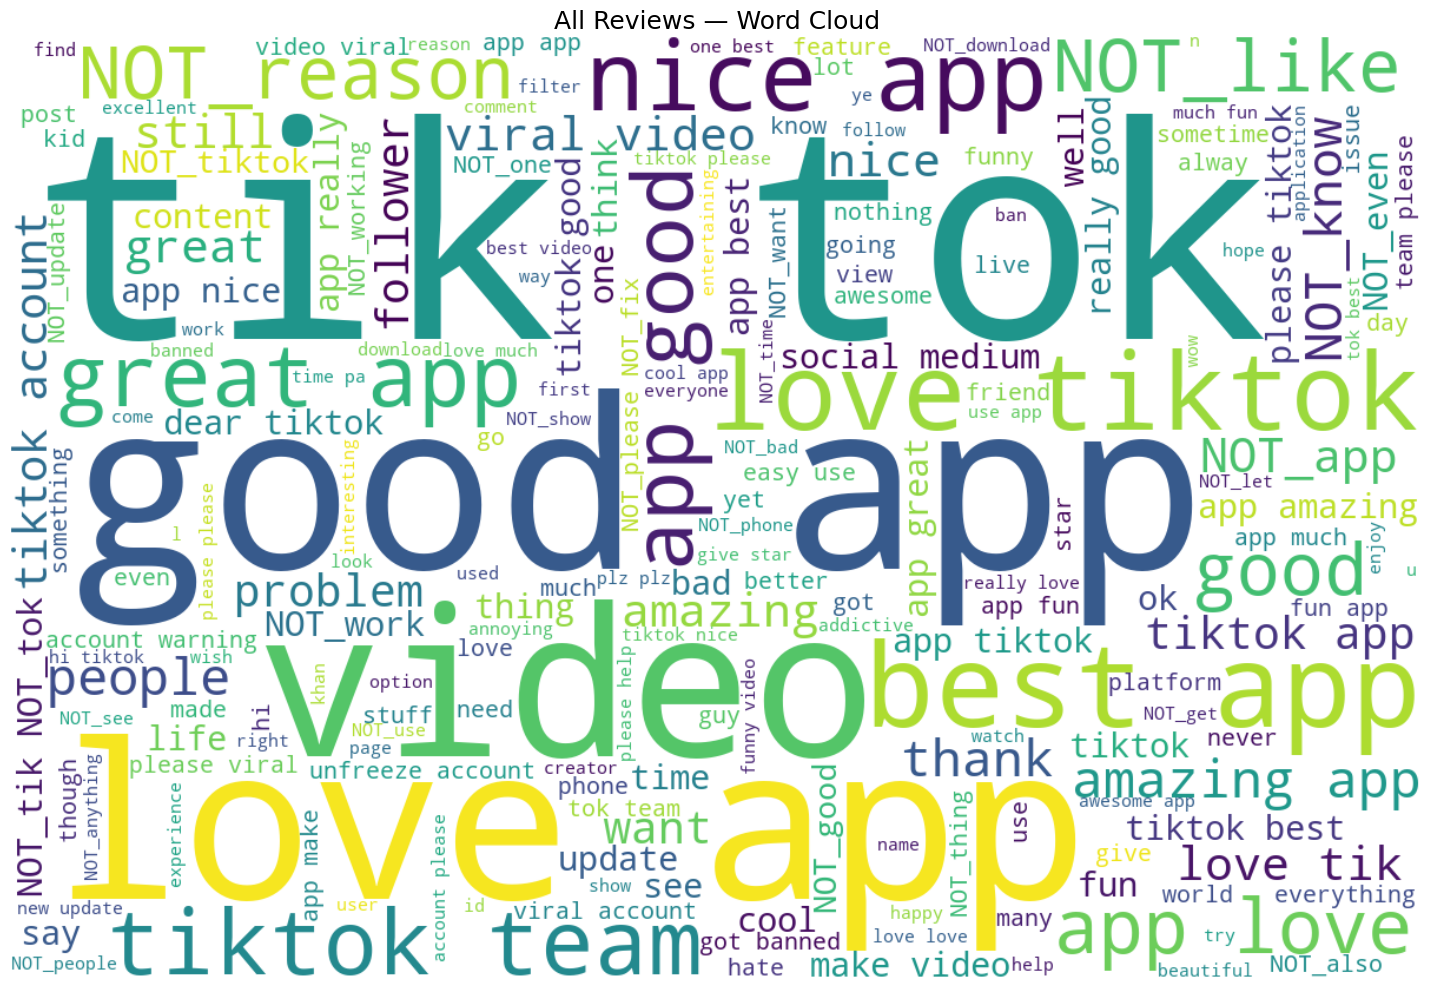

In [20]:
# overall word cloud (cleaned text)
wc_stopwords = set(STOPWORDS)

all_text = " ".join(data["clean_content"])
wordcloud = WordCloud(
    stopwords=wc_stopwords,
    background_color="white",
    width=1200,
    height=800,
).generate(all_text)

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("All Reviews — Word Cloud", fontsize=18)
plt.tight_layout()
plt.show()

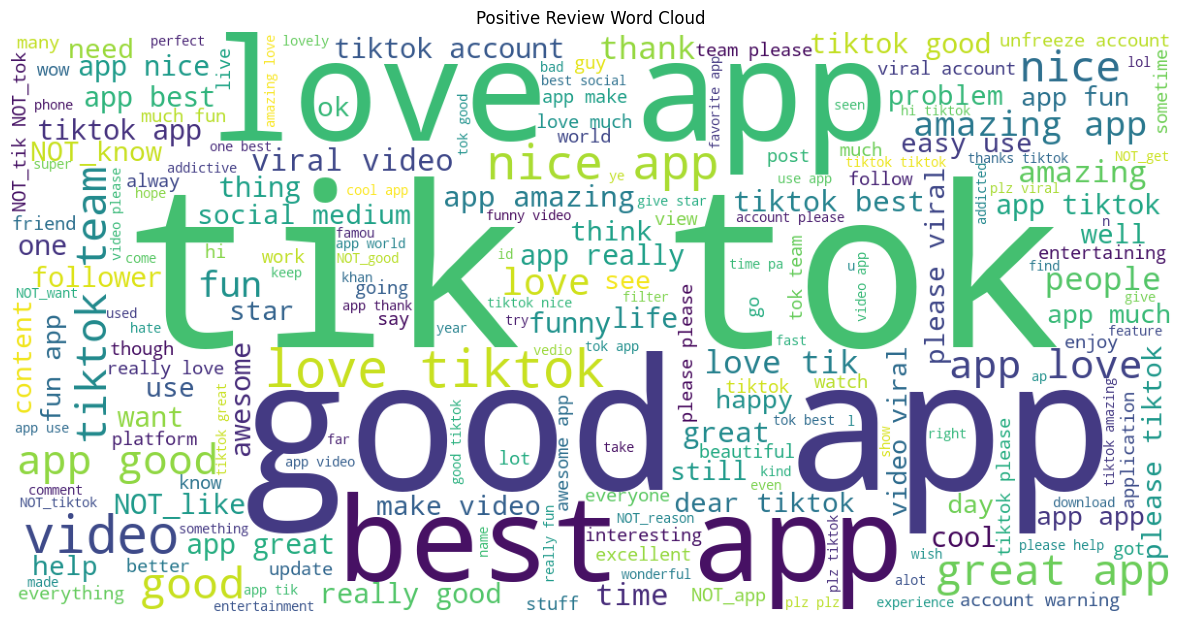

In [21]:
# positive word cloud
positive_text = " ".join(data[data["sentiment"] == "positive"]["clean_content"])

wordcloud = WordCloud(
    stopwords=set(STOPWORDS), background_color="white", width=1200, height=600
).generate(positive_text)

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Review Word Cloud")
plt.show()

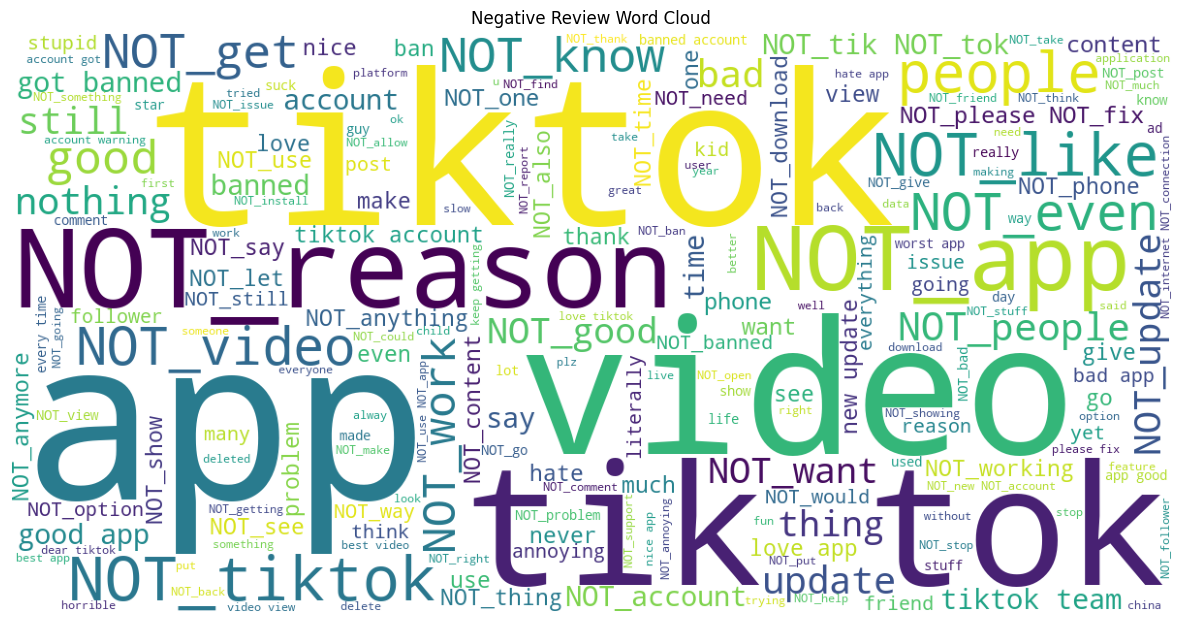

In [28]:
# negative word cloud
negative_text = " ".join(data[data["sentiment"] == "negative"]["clean_content"])

wordcloud = WordCloud(
    stopwords=set(STOPWORDS), background_color="white", width=1200, height=600
).generate(negative_text)

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Review Word Cloud")
plt.show()

In [31]:
# Sentiment analysis
#    VADER runs on ORIGINAL content (natural language, not cleaned/lemmatized)
#    cleaned_content is used for word clouds & text-based tasks

sid = SentimentIntensityAnalyzer()

data["Positive"] = [sid.polarity_scores(i)["pos"] for i in data["content"]]
data["Negative"] = [sid.polarity_scores(i)["neg"] for i in data["content"]]
data["Neutral"]  = [sid.polarity_scores(i)["neu"] for i in data["content"]]
data["Compound"] = [sid.polarity_scores(i)["compound"] for i in data["content"]]

# Compound-based label (standard VADER threshold)
data["Sentiment_Label"] = data["Compound"].apply(
    lambda c: "Positive" if c >= 0.05 else ("Negative" if c <= -0.05 else "Neutral")
)

print("\nSentiment distribution:")
print(data["Sentiment_Label"].value_counts())
print(data[["content", "Positive", "Negative", "Neutral", "Compound", "Sentiment_Label"]].head())



Sentiment distribution:
Sentiment_Label
Positive    152594
Neutral      97654
Negative     37030
Name: count, dtype: int64
                                             content  Positive  Negative  \
0                                           No words     0.000     0.688   
1                              Great fun app so far!     0.719     0.000   
2  The app would get a higher rating but I litera...     0.000     0.073   
3  I WISH I COULD GIVE THIS A 100 PERCENT RATING ...     0.561     0.000   
4                                Pictures and record     0.000     0.000   

   Neutral  Compound Sentiment_Label  
0    0.312   -0.2960        Negative  
1    0.281    0.8268        Positive  
2    0.927   -0.6297        Negative  
3    0.439    0.8735        Positive  
4    1.000    0.0000         Neutral  


In [32]:
# overall sentiment analysis
x = data["Positive"].sum()
y = data["Negative"].sum()
z = data["Neutral"].sum()


def sentiment_score(a, b, c):
    if (a > b) and (a > c):
        print("Overall Sentiment: Positive 😊")
    elif (b > a) and (b > c):
        print("Overall Sentiment: Negative 😠")
    else:
        print("Overall Sentiment: Neutral 🙂")


sentiment_score(x, y, z)

print(f"\nPositive score sum : {x:,.2f}")
print(f"Negative score sum : {y:,.2f}")
print(f"Neutral score sum  : {z:,.2f}")

Overall Sentiment: Neutral 🙂

Positive score sum : 74,743.89
Negative score sum : 14,117.04
Neutral score sum  : 197,738.09


In [33]:
# Sentiment label bar chart
label_counts = data["Sentiment_Label"].value_counts()
fig = px.bar(
    x=label_counts.index,
    y=label_counts.values,
    color=label_counts.index,
    color_discrete_map={"Positive": "green", "Negative": "red", "Neutral": "gray"},
    title="Review Sentiment Distribution (Compound Score)",
    labels={"x": "Sentiment", "y": "Count"},
)
fig.show()